## Tesla and GameStop Stock and Revenue Analysis


## Project Overview

This project analyzes the historical stock prices and quarterly revenue of Tesla and GameStop using Python. The objective is to collect financial data, clean and process the datasets, and visualize stock price and revenue trends over time.

## Objectives

- Extract historical stock price data for Tesla and GameStop.
- Extract quarterly revenue data.
- Clean and prepare the datasets using Pandas.
- Visualize stock price and revenue trends.
- Compare stock price movements with revenue trends.

## Tools & Technologies

- Python
- Pandas
- yfinance
- Matplotlib
- Jupyter Notebook

## Companies Analyzed

### Tesla (TSLA)

Historical stock price and quarterly revenue data for Tesla.

### GameStop (GME)

Historical stock price and quarterly revenue data for GameStop.


## 1. Importing Libraries

In [31]:
import yfinance as yf;
import pandas as pd;
import warnings;
import matplotlib.pyplot as plt

## 2. Tesla Stock Data

In [32]:
Tesla = yf.Ticker("TSLA")
tesla_data = Tesla.history(period="max")
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


## 3. Tesla Revenue Data

In [33]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm " 
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
tables = pd.read_html(url)
tesla_revenue = tables[1]
tesla_revenue.columns = ['Date', 'Revenue']
tesla_revenue['Revenue'] = tesla_revenue['Revenue'].str.replace(',|\$','', regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue']!='']
print(tesla_revenue.tail(5))

          Date Revenue
48  2010-09-30      31
49  2010-06-30      28
50  2010-03-31      21
52  2009-09-30      46
53  2009-06-30      27


The Tesla revenue dataset contains historical quarterly revenue information. The revenue values were cleaned by removing currency symbols and commas and by removing missing values.

## 4. GameStop Stock Data

In [34]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
gamestop = yf.Ticker("GME")
gme_data = gamestop.history(period = "max")
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


## 5. GameStop Revenue Data

In [35]:
tables = pd.read_html(url, match="GameStop Quarterly Revenue")
gme_revenue = tables[0]
gme_revenue.columns = ['Date', 'Revenue']
gme_revenue['Revenue'] = gme_revenue['Revenue'].str.replace(",|\$",'', regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue']!='']
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


Here, we have altered the columns of our dataFrame to Date and Revenue for seamless plotting, replaced the ',' and '$' signs from the revenue column to facilitate accurate plotting of our data, dropped the NaN values from the dataFrame and deleted the rows that contained blank values displaying the last 5 rows of our dataframe.

## 6. Data Visualization

A reusable function was created to visualize historical stock prices and quarterly revenue for each company. The function accepts stock data, revenue data, and the company name as inputs.

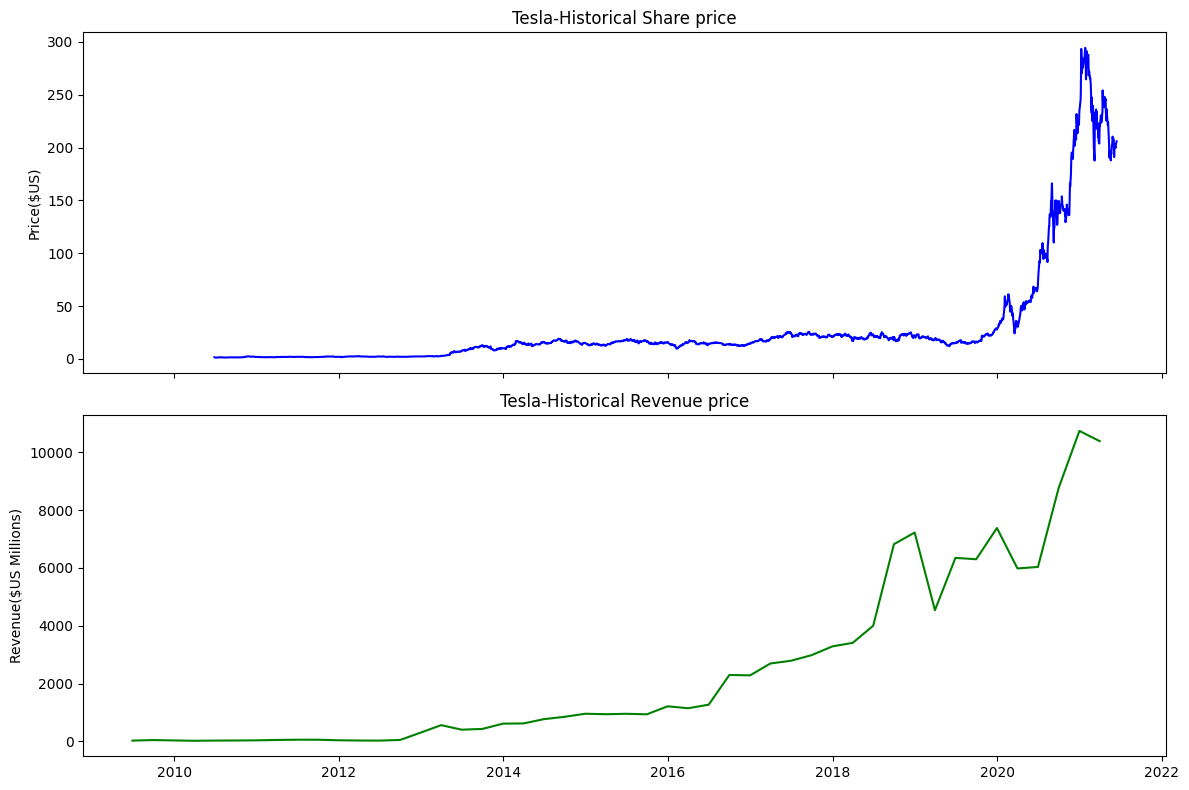

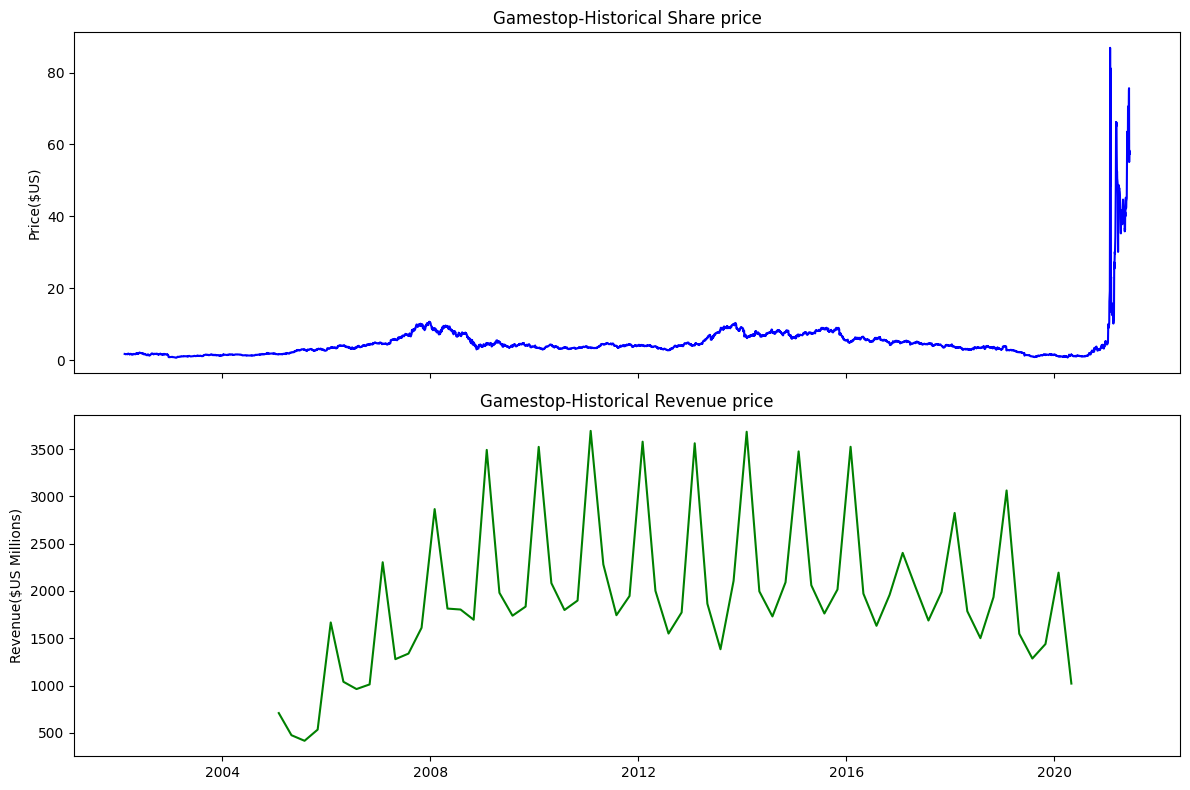

In [36]:
# Ignores all warnings 
warnings.filterwarnings('ignore',category=FutureWarning)
#Defining the function makegraph that accepts the stock data dataframe(cols = Date and close), revenue dataframe that accepts(cols = Date and revenue) and the stock name 
def makegraph(stock_data, revenue_data, stock):
    stock_specific_data = stock_data[stock_data.Date<='2021-06-14']
    revenue_specific_data = revenue_data[revenue_data.Date<='2021-04-30']
    fig,axes = plt.subplots(2,1,figsize = (12,8),sharex=True)
    # Stock Data 
    axes[0].plot(pd.to_datetime(stock_specific_data.Date),stock_specific_data.Close.astype('float'), label = "share-price", color = "blue")
    axes[0].set_ylabel("Price($US)")
    axes[0].set_title(f"{stock}-Historical Share price")
    #Revenue data
    axes[1].plot(pd.to_datetime(revenue_specific_data.Date),revenue_specific_data.Revenue.astype('float'), label = "Revenue", color = "green")
    axes[1].set_ylabel("Revenue($US Millions)")
    axes[1].set_title(f"{stock}-Historical Revenue price")
    plt.tight_layout()
    plt.show()

#Plotting tesla and gamestop stock graph 
makegraph(tesla_data,tesla_revenue,'Tesla')
makegraph(gme_data, gme_revenue,'Gamestop')

## 7. Analysis and findings 

### Tesla Stock Price

- Tesla's stock price shows an overall upward trend during the analyzed period, with substantial appreciation toward the end of the period despite a slight decline near the peak.

- Tesla's revenue remained relatively stable during the earlier years, followed by gradual growth and a stronger upward trend in the later part of the analyzed period.

- Overall, Tesla's stock price and revenue generally moved in the same upward direction. The increase in revenue was particularly strong during the later years, while the stock price also experienced substantial growth.

- This suggests that Tesla's improving revenue performance coincided with strong growth in its share price during the period analyzed.

### Tesla Revenue price 
- Between 2010 and 2012, Tesla's revenue remained relatively low and stable.

- From approximately 2013 onward, Tesla's revenue began to increase, with continued growth throughout the following years despite some fluctuations.

- Revenue experienced a stronger upward trend from around 2017 onward, with some temporary declines during the period.

- From 2020 into 2021, Tesla's revenue increased substantially and reached its highest level in the analyzed period.

### GameStop Stock Price

- GameStop's stock price experienced relatively modest growth between 2004 and 2008, reaching a local peak around 2008.

- Following this peak, the stock price declined and remained relatively stable through approximately 2012.

- Between 2012 and 2016, the stock price experienced another period of growth before declining again around 2016.

- From 2016 through 2020, the stock price remained on a general downward trend.

- Shortly after 2020, GameStop's stock price experienced a substantial increase, representing the most significant price movement in the period analyzed.

### GameStop Revenue Price
- Between 2004 and 2008, GameStop's revenue increased substantially overall, although the trend fluctuated from period to period, reaching a peak around 2008.

- Between 2008 and 2012, revenue continued to fluctuate significantly, with repeated increases and decreases while remaining at relatively high levels.

- Between 2012 and 2016, revenue remained relatively high but continued to show substantial fluctuations, with several significant peaks and declines.

- From 2016 to 2020, GameStop's revenue showed an overall downward trend, although quarterly revenue continued to fluctuate. Revenue reached one of its lowest levels toward the end of the period.

## Conclusion

This project analyzed historical stock prices and quarterly revenue for Tesla and GameStop using Python. Tesla's stock price and revenue generally followed an upward trend over the analyzed period, although both experienced periods of fluctuation.

GameStop showed a different pattern. While its revenue generally weakened toward the latter part of the period, its stock price experienced an exceptionally large increase after 2020. This demonstrates that stock price movements do not always follow the same pattern as company revenue.

The project provided practical experience in collecting, cleaning, analyzing, and visualizing financial data using Python.